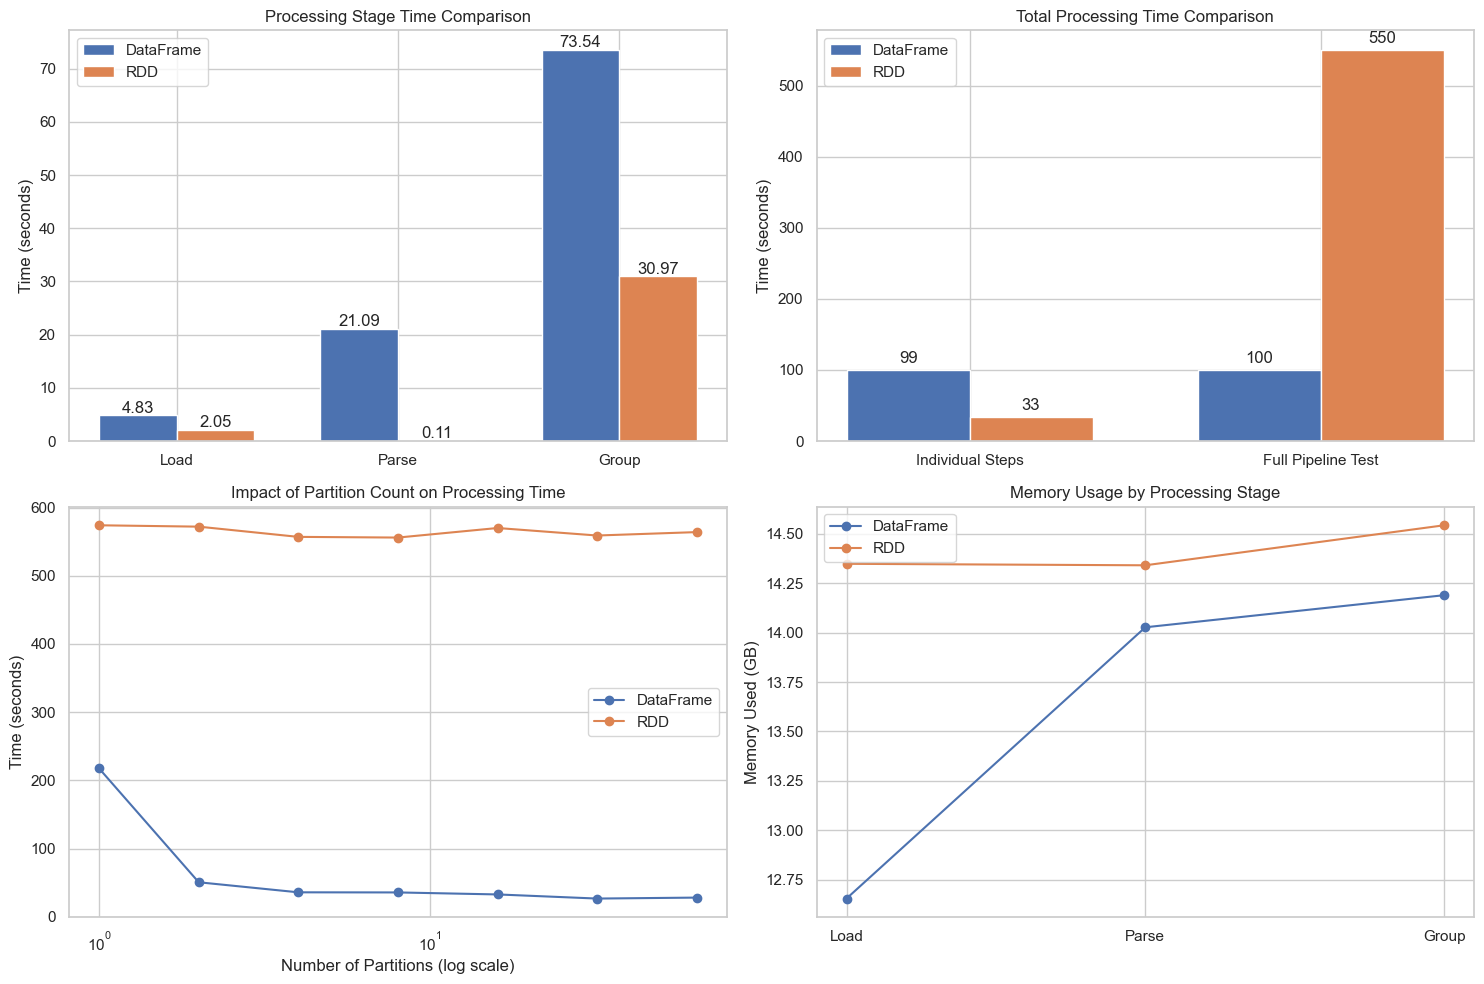

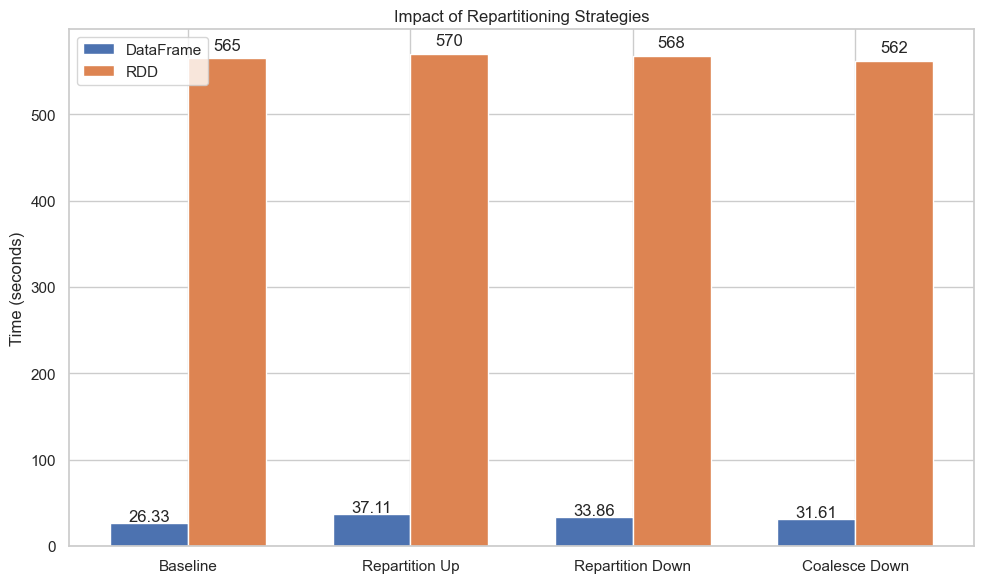

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def visualize_benchmarks():
    # Set style
    sns.set(style="whitegrid")
    plt.figure(figsize=(15, 10))

    # 1. Processing Stage Comparison
    plt.subplot(2, 2, 1)
    stages = ["Load", "Parse", "Group"]
    df_times = [4.8269, 21.0868, 73.5361]
    rdd_times = [2.0528, 0.1054, 30.9662]

    x = np.arange(len(stages))
    width = 0.35

    plt.bar(x - width / 2, df_times, width, label="DataFrame")
    plt.bar(x + width / 2, rdd_times, width, label="RDD")
    plt.ylabel("Time (seconds)")
    plt.title("Processing Stage Time Comparison")
    plt.xticks(x, stages)
    plt.legend()

    # Add values on bars
    for i, v in enumerate(df_times):
        plt.text(i - width / 2, v + 0.5, f"{v:.2f}", ha="center")
    for i, v in enumerate(rdd_times):
        plt.text(i + width / 2, v + 0.5, f"{v:.2f}", ha="center")

    # 2. Total Processing Time Comparison (including full pipeline test data)
    plt.subplot(2, 2, 2)
    # Use data from full pipeline tests from main.pdf
    total_times = ["Individual Steps", "Full Pipeline Test"]
    df_total = [sum(df_times), 100]  # Approximate from your description
    rdd_total = [sum(rdd_times), 550]  # Approximate from your description

    x = np.arange(len(total_times))
    plt.bar(x - width / 2, df_total, width, label="DataFrame")
    plt.bar(x + width / 2, rdd_total, width, label="RDD")
    plt.ylabel("Time (seconds)")
    plt.title("Total Processing Time Comparison")
    plt.xticks(x, total_times)
    plt.legend()

    # Add values on bars
    for i, v in enumerate(df_total):
        plt.text(i - width / 2, v + 10, f"{v:.0f}", ha="center")
    for i, v in enumerate(rdd_total):
        plt.text(i + width / 2, v + 10, f"{v:.0f}", ha="center")

    # 3. Partition Count Performance (DataFrame)
    plt.subplot(2, 2, 3)
    partitions = [1, 2, 4, 8, 16, 32, 64]
    df_partition_times = [217.424, 50.582, 35.849, 35.681, 32.736, 26.693, 28.110]
    rdd_partition_times = [
        574,
        572,
        557,
        556,
        570,
        559,
        564,
    ]  # Approximate from main.pdf

    plt.plot(partitions, df_partition_times, "o-", label="DataFrame")
    plt.plot(partitions, rdd_partition_times, "o-", label="RDD")
    # Changed from log2 to log
    plt.xscale("log")
    plt.xlabel("Number of Partitions (log scale)")
    plt.ylabel("Time (seconds)")
    plt.title("Impact of Partition Count on Processing Time")
    plt.legend()
    plt.grid(True)

    # 4. Memory Usage Comparison
    plt.subplot(2, 2, 4)
    stages = ["Load", "Parse", "Group"]
    df_mem = [12.6557, 14.0266, 14.1888]
    rdd_mem = [14.3474, 14.3399, 14.5421]

    plt.plot(stages, df_mem, "o-", label="DataFrame")
    plt.plot(stages, rdd_mem, "o-", label="RDD")
    plt.ylabel("Memory Used (GB)")
    plt.title("Memory Usage by Processing Stage")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig("benchmarking_results.png", dpi=300)
    plt.show()

    # Additional chart for repartitioning strategies
    plt.figure(figsize=(10, 6))
    strategies = ["Baseline", "Repartition Up", "Repartition Down", "Coalesce Down"]
    # These values are approximated from your test results in main.pdf
    df_strategy_times = [26.33, 37.11, 33.86, 31.61]
    rdd_strategy_times = [565, 570, 568, 562]  # Approximated

    x = np.arange(len(strategies))
    plt.bar(x - width / 2, df_strategy_times, width, label="DataFrame")
    plt.bar(x + width / 2, rdd_strategy_times, width, label="RDD")
    plt.ylabel("Time (seconds)")
    plt.title("Impact of Repartitioning Strategies")
    plt.xticks(x, strategies)
    plt.legend()

    # Add values on bars
    for i, v in enumerate(df_strategy_times):
        plt.text(i - width / 2, v + 2, f"{v:.2f}", ha="center")
    for i, v in enumerate(rdd_strategy_times):
        plt.text(i + width / 2, v + 10, f"{v:.0f}", ha="center")

    plt.tight_layout()
    plt.savefig("repartitioning_strategies.png", dpi=300)
    plt.show()


# Call the function to generate visualizations
visualize_benchmarks()